In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
print("shape of the dataset:",df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDatatypes:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicated Values:\n")
print(df.duplicated().sum())

shape of the dataset: (1000, 8)

Columns:

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

Datatypes:

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

Missing Values:

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicated Values:

0


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.columns = [
    "gender",
    "race_ethnicity",
    "parental_level_of_education",
    "lunch",
    "test_preparation_course",
    "math_score",
    "reading_score",
    "writing_score"
]

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'object']

numerical_features = [feature for feature in df.columns if df[feature].dtype == 'int64']

print("categorical feature count:",len(categorical_features))
print("numerical feature count:",len(numerical_features))

print("\nCategorical Features:\n")
print(categorical_features)

print("\nNumerical Features:\n")
print(numerical_features)

categorical feature count: 0
numerical feature count: 3

Categorical Features:

[]

Numerical Features:

['math_score', 'reading_score', 'writing_score']


In [9]:
for col in categorical_features:
    print(f"\nCategories in {col}:")
    print(df[col].value_counts())

In [10]:
df["average_score"]=(
    df["math_score"]+df["reading_score"]+df["writing_score"]
)/3

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


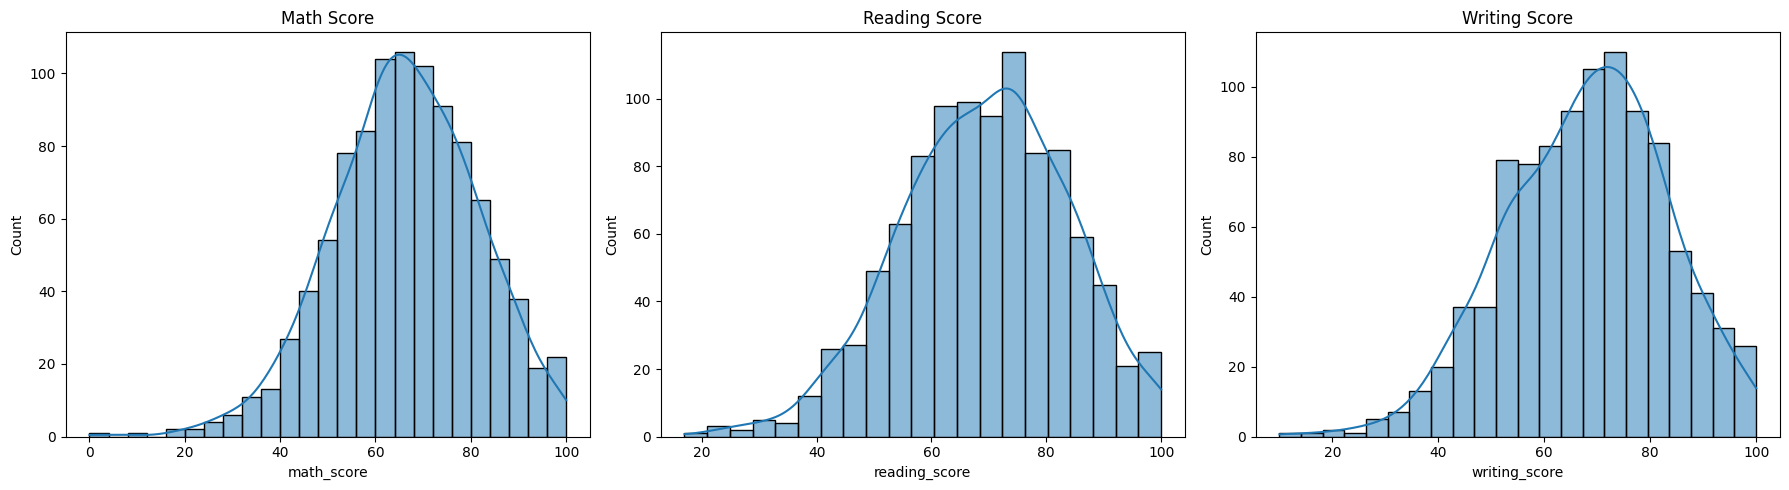

In [11]:
fig, axs = plt.subplots(1,3,figsize=(18,5))

sns.histplot(df["math_score"],ax=axs[0],kde=True)
axs[0].set_title("Math Score")

sns.histplot(df["reading_score"],ax=axs[1],kde=True)
axs[1].set_title("Reading Score")

sns.histplot(df["writing_score"],ax=axs[2],kde=True)
axs[2].set_title("Writing Score")

plt.tight_layout()
plt.show()

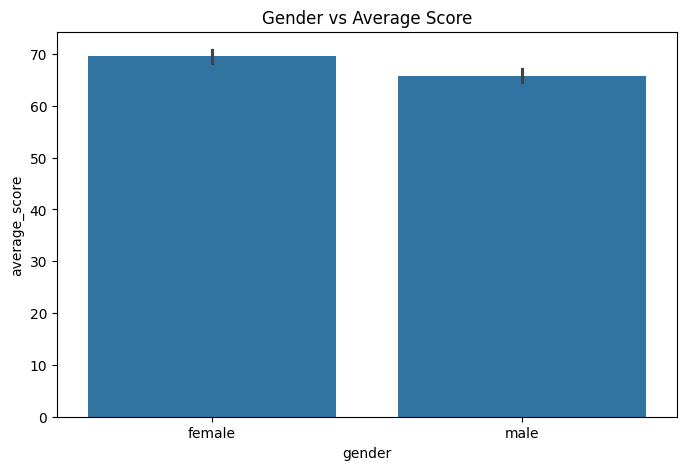

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="gender",
    y="average_score",
    data=df
)
plt.title("Gender vs Average Score")
plt.show()

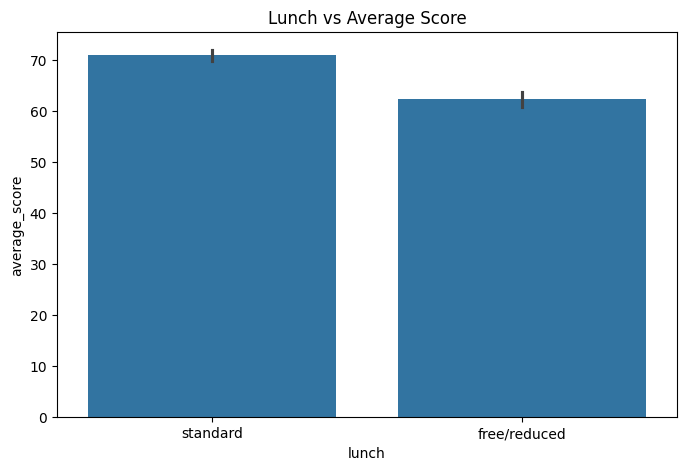

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="lunch",
    y="average_score",
    data=df
)

plt.title("Lunch vs Average Score")
plt.show()

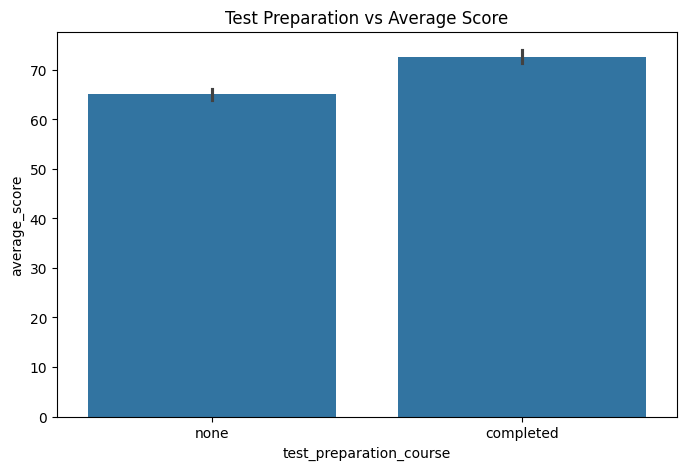

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="test_preparation_course",
    y="average_score",
    data=df
)

plt.title("Test Preparation vs Average Score")
plt.show()

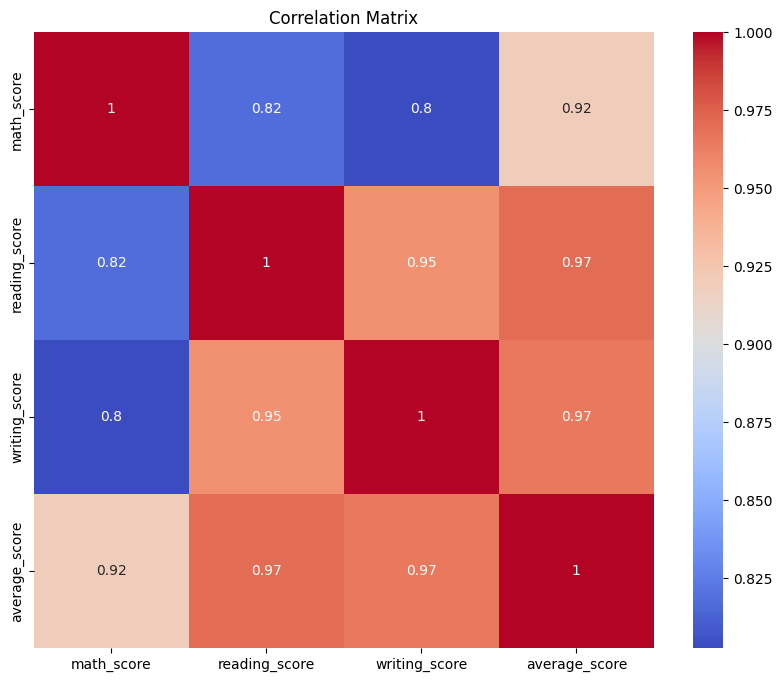

In [15]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

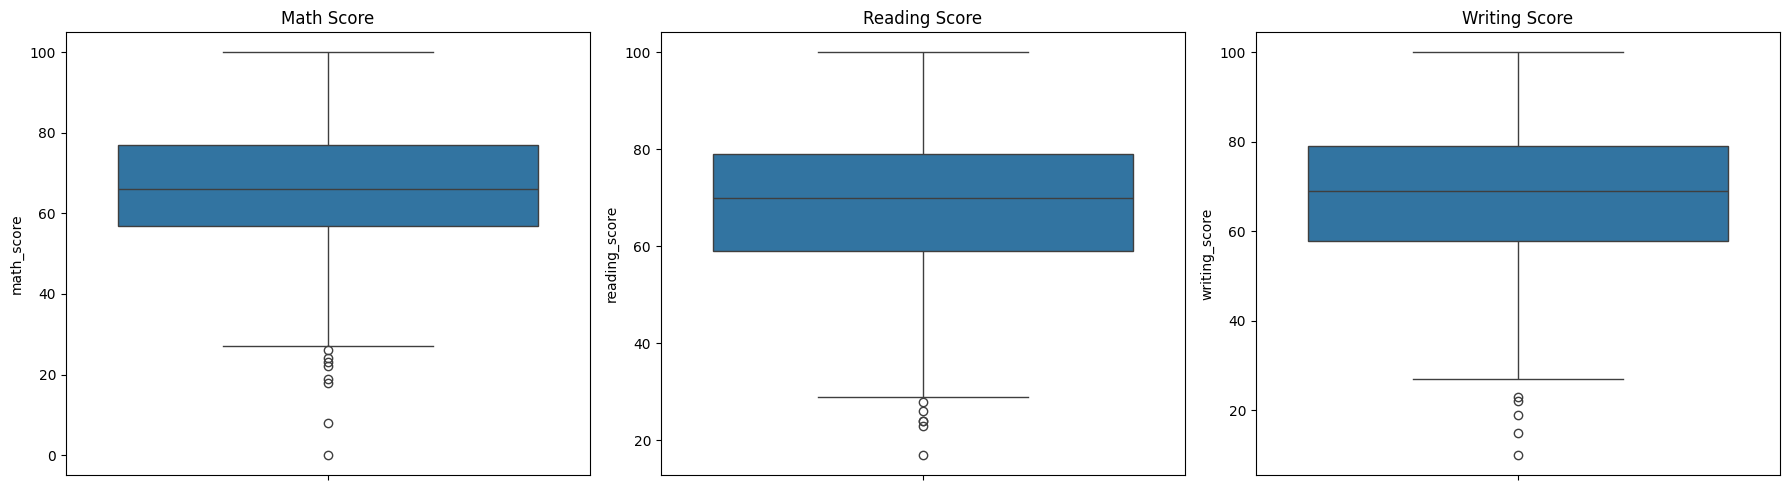

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df["math_score"], ax=axs[0])
axs[0].set_title("Math Score")

sns.boxplot(y=df["reading_score"], ax=axs[1])
axs[1].set_title("Reading Score")

sns.boxplot(y=df["writing_score"], ax=axs[2])
axs[2].set_title("Writing Score")

plt.tight_layout()
plt.show()

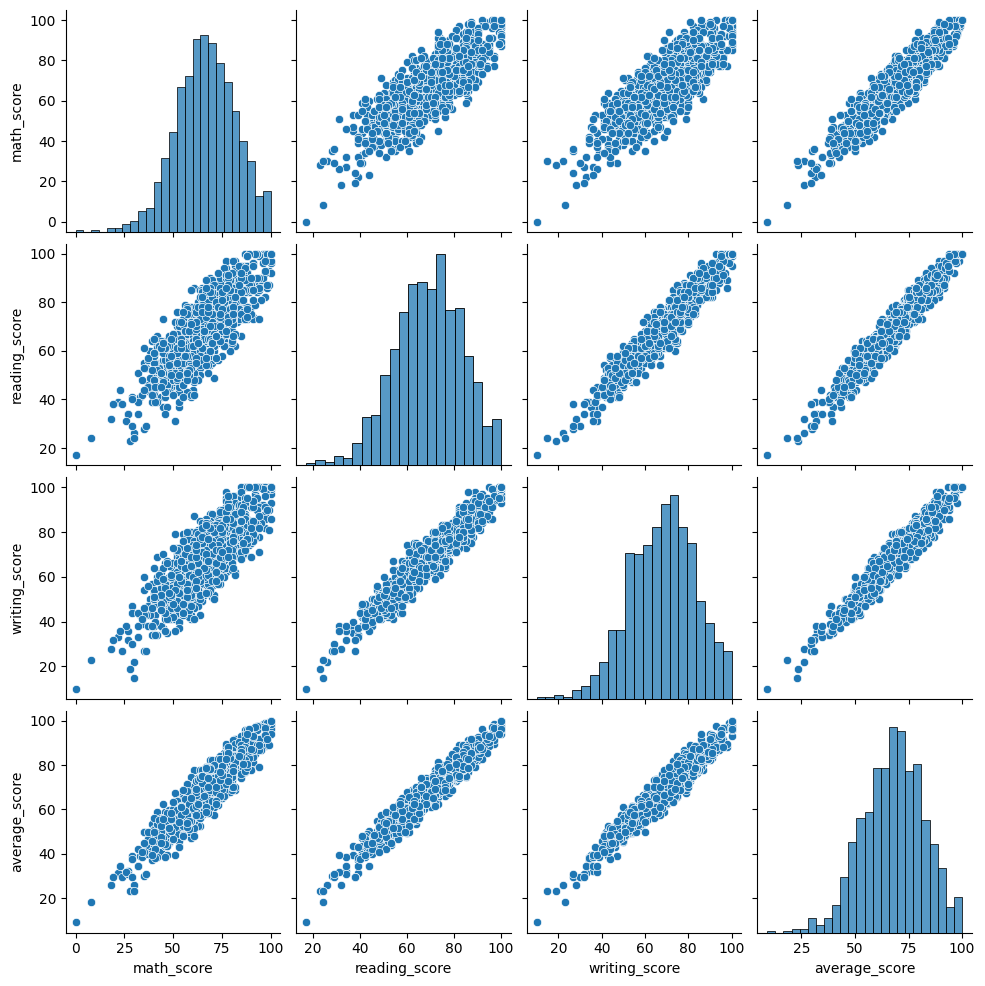

In [17]:
sns.pairplot(df)
plt.show()

In [18]:
df.to_csv("cleaned_student_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
